**DeepONet using DeepXDE module**

In [2]:
import deepxde as dde
import matplotlib.pyplot as plt
import numpy as np
import h5py
from sklearn.model_selection import train_test_split
from torch.optim.lr_scheduler import ReduceLROnPlateau

Using backend: pytorch
Other supported backends: tensorflow.compat.v1, tensorflow, jax, paddle.
paddle supports more examples now and is recommended.


Data loading

In [3]:
datastore = h5py.File("C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/datasets/trials_many_alldata_new_eqution_halton.h5", 'r')
data_I = np.array(np.array(datastore["I"]))

data_c = np.array(np.array(datastore["c"]))
data_h = np.array(np.array(datastore["h"]))
t = np.linspace(0, 1, 601).reshape(601, 1)

Train-test split

In [4]:
train_label, test_label = train_test_split(range(len(data_I)), test_size=0.25, random_state=42)

data_i_train = data_I[train_label,:]
data_i_test = data_I[test_label,:]

data_c_train = data_c[train_label,:]
data_c_test = data_c[test_label,:]

data_h_train = data_h[train_label,:]
data_h_test = data_h[test_label,:]

In [5]:
num_rows = np.sum(np.max(data_c, axis=1) < 2)
print(f"Number of rows in data_c where the maximum value is less than 2: {num_rows}")

Number of rows in data_c where the maximum value is less than 2: 98733


In [6]:
# Define a threshold for standard deviation to consider c as almost constant
threshold = 0.01

# Calculate the standard deviation of each row in data_c
std_devs = np.std(data_c, axis=1)

# Count the number of rows where the standard deviation is below the threshold
num_constant_rows = np.sum(std_devs < threshold)
print(f"Number of rows in data_c where c is almost constant: {num_constant_rows}")

Number of rows in data_c where c is almost constant: 5139


In [7]:
# Define a threshold for standard deviation to consider c as almost constant
threshold = 0.01

# Calculate the standard deviation of each row in data_c
std_devs = np.std(data_c, axis=1)

# Separate out the rows where the standard deviation is below the threshold
constant_rows = data_c[std_devs < threshold]
constant_rows_indices = np.where(std_devs < threshold)[0].tolist()
constant_rows_h = data_h[constant_rows_indices]
non_constant_rows = data_c[std_devs >= threshold]

print(f"Number of rows where c is almost constant: {constant_rows.shape[0]}")
print(f"Number of rows where c is not constant: {non_constant_rows.shape[0]}")

Number of rows where c is almost constant: 5139
Number of rows where c is not constant: 101276


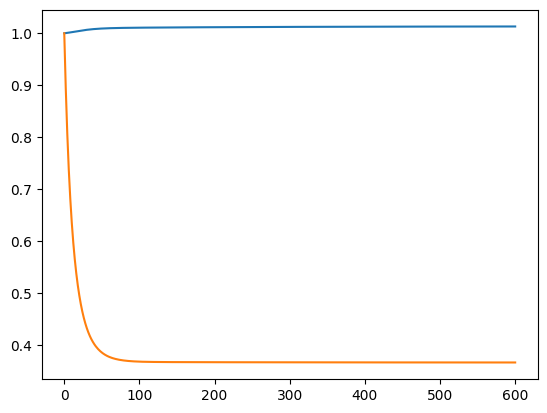

In [8]:
plt.plot(constant_rows[33])
plt.plot(constant_rows_h[33])

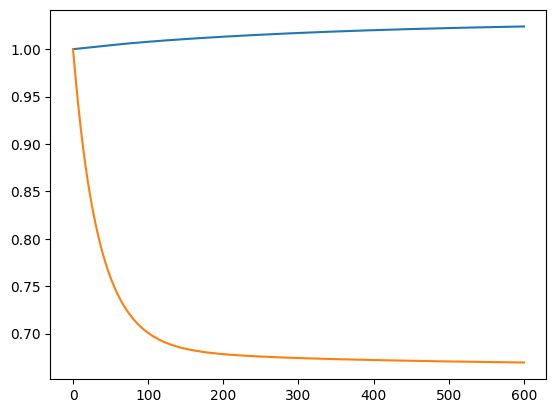

In [9]:
plt.plot(constant_rows[24])
plt.plot(constant_rows_h[24])

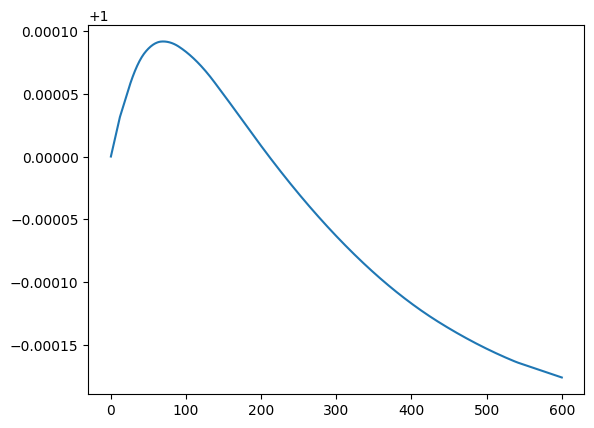

In [10]:
plt.plot(constant_rows[4])

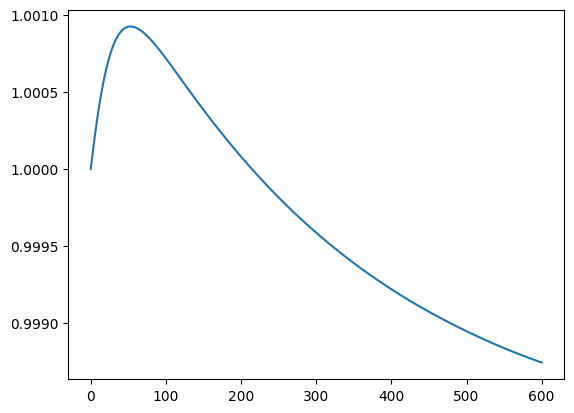

In [11]:
plt.plot(constant_rows[18])

In [12]:
from sklearn.decomposition import PCA
from sklearn.metrics import explained_variance_score

# Train PCA model
pca = PCA(n_components=0.9999, svd_solver='full')
pca.fit(data_i_train)

# Transform data_c_test using the trained PCA model
data_c_test_pca = pca.transform(data_c_test)

# Inverse transform to get the reconstructed data
data_c_test_reconstructed = pca.inverse_transform(data_c_test_pca)

# Calculate explained variance score
explained_variance = explained_variance_score(data_c_test, data_c_test_reconstructed)
print(f"Explained Variance Score: {explained_variance}")

Explained Variance Score: -6.731675894766282e+21


In [13]:
# from sklearn.metrics import mean_squared_error

# Train PCA model
pca_i = PCA(n_components=0.999, svd_solver='full')
pca_i.fit(data_i_train)

# Number of principal components
n_components = pca_i.n_components_
print(f"Number of principal components: {n_components}")

# Transform and inverse transform data_i_train
data_i_train_pca = pca_i.transform(data_i_train)
data_i_train_reconstructed = pca_i.inverse_transform(data_i_train_pca)

# Calculate mean squared error for data_i_train
mse_train = np.mean((data_i_train - data_i_train_reconstructed)**2)
print(f"Mean Squared Error for data_i_train: {mse_train}")

# Transform and inverse transform data_i_test
data_i_test_pca = pca_i.transform(data_i_test)
data_i_test_reconstructed = pca_i.inverse_transform(data_i_test_pca)

# Calculate mean squared error for data_i_test
mse_test = np.mean((data_i_test - data_i_test_reconstructed)**2)
print(f"Mean Squared Error for data_i_test: {mse_test}")

Number of principal components: 7
Mean Squared Error for data_i_train: 7.822254895071664e-06
Mean Squared Error for data_i_test: 8.408897649399122e-06


In [14]:
X_train = (data_i_train_pca.astype(np.float32), t.astype(np.float32))
y_train_c = data_c_train.astype(np.float32)

In [15]:
X_test = (data_i_test_pca.astype(np.float32), t.astype(np.float32))
y_test_c = data_c_test.astype(np.float32)

**Making the data compatible with deepxde.nn.pytorch.deeponet.PODDeepONet**

In [16]:
data_c = dde.data.TripleCartesianProd(
    X_train=X_train, y_train=y_train_c, X_test=X_test, y_test=y_test_c
)

In [21]:
m = 7
dim_x = 1
net = dde.nn.DeepONetCartesianProd(
    [m, 300, 300, 100],
    [dim_x, 200, 200, 100],
    "relu",
    "Glorot normal",
)

**Counting the number of learnable parameters in the model**

In [22]:
def compute_parameters(layers):
    params = 0
    for i in range(len(layers) - 1):
        params += layers[i] * layers[i + 1]  # Weights
        params += layers[i + 1]             # Biases
    return params

branch_layers = [m, 300, 300, 100]
trunk_layers = [dim_x, 200, 200, 100]

branch_params = compute_parameters(branch_layers)
trunk_params = compute_parameters(trunk_layers)
total_params = branch_params + trunk_params
print(f"Total trainable parameters: {total_params}, branch parameters: {branch_params}, trunk parameters: {trunk_params}")


Total trainable parameters: 183500, branch parameters: 122800, trunk parameters: 60700


**Training the model**

In [23]:
model_c = dde.Model(data_c, net)
# lr = ReduceLROnPlateau(optimizer_combined, mode='min', factor=0.5, patience=5)
model_c.compile("adam", lr=0.001)
# path = "C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/model_c_deeponet_pca-2000.pt"
# model_c.restore(path)
losshistory_c, train_state_c = model_c.train(iterations=2000, display_every=100)

Compiling model...
'compile' took 0.000427 s

Training model...

Step      Train loss    Test loss     Test metric
0         [1.24e+00]    [1.24e+00]    []  
100       [1.94e-02]    [2.00e-02]    []  
200       [1.34e-02]    [1.37e-02]    []  
300       [1.34e-02]    [1.37e-02]    []  
400       [9.39e-03]    [9.61e-03]    []  
500       [7.90e-03]    [8.02e-03]    []  
600       [8.00e-03]    [8.08e-03]    []  
700       [5.93e-03]    [6.03e-03]    []  
800       [5.68e-03]    [5.75e-03]    []  
900       [8.10e-03]    [8.14e-03]    []  
1000      [4.58e-03]    [4.68e-03]    []  
1100      [4.35e-03]    [4.44e-03]    []  
1200      [4.63e-03]    [4.72e-03]    []  
1300      [3.91e-03]    [4.02e-03]    []  
1400      [4.40e-03]    [4.50e-03]    []  
1500      [5.78e-03]    [5.89e-03]    []  
1600      [3.48e-03]    [3.60e-03]    []  
1700      [3.39e-03]    [3.51e-03]    []  
1800      [3.49e-03]    [3.61e-03]    []  
1900      [3.25e-03]    [3.37e-03]    []  
2000      [3.80e-03]    [

In [28]:
y_train_h = data_h_train.astype(np.float32)
y_test_h = data_h_test.astype(np.float32)

In [29]:
data_h = dde.data.TripleCartesianProd(
    X_train=X_train, y_train=y_train_h, X_test=X_test, y_test=y_test_h
)

In [30]:
m = 7
dim_x = 1
net = dde.nn.DeepONetCartesianProd(
    [m, 300, 200, 100],
    [dim_x, 300, 200, 100],
    "relu",
    "Glorot normal",
)

In [31]:
model_h = dde.Model(data_h, net)
# lr = ReduceLROnPlateau(optimizer_combined, mode='min', factor=0.5, patience=5)
model_h.compile("adam", lr=0.001)
# path = "C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/model_h_deeponet_pca-2000.pt"
# model_h.restore(path)
losshistory_h, train_state_h = model_h.train(iterations=2000, display_every=100)

Compiling model...
'compile' took 0.000309 s

Training model...

Step      Train loss    Test loss     Test metric
0         [2.72e-01]    [2.70e-01]    []  
100       [2.11e-02]    [2.12e-02]    []  
200       [1.46e-02]    [1.45e-02]    []  
300       [8.59e-03]    [8.64e-03]    []  
400       [6.54e-03]    [6.64e-03]    []  
500       [6.19e-03]    [6.28e-03]    []  
600       [4.84e-03]    [4.90e-03]    []  
700       [4.29e-03]    [4.35e-03]    []  
800       [4.55e-03]    [4.60e-03]    []  
900       [3.57e-03]    [3.61e-03]    []  
1000      [3.74e-03]    [3.78e-03]    []  
1100      [3.62e-03]    [3.65e-03]    []  
1200      [3.18e-03]    [3.21e-03]    []  
1300      [3.13e-03]    [3.15e-03]    []  
1400      [3.15e-03]    [3.18e-03]    []  
1500      [3.28e-03]    [3.31e-03]    []  
1600      [3.24e-03]    [3.27e-03]    []  
1700      [3.09e-03]    [3.10e-03]    []  
1800      [2.64e-03]    [2.66e-03]    []  
1900      [2.77e-03]    [2.79e-03]    []  
2000      [2.88e-03]    [

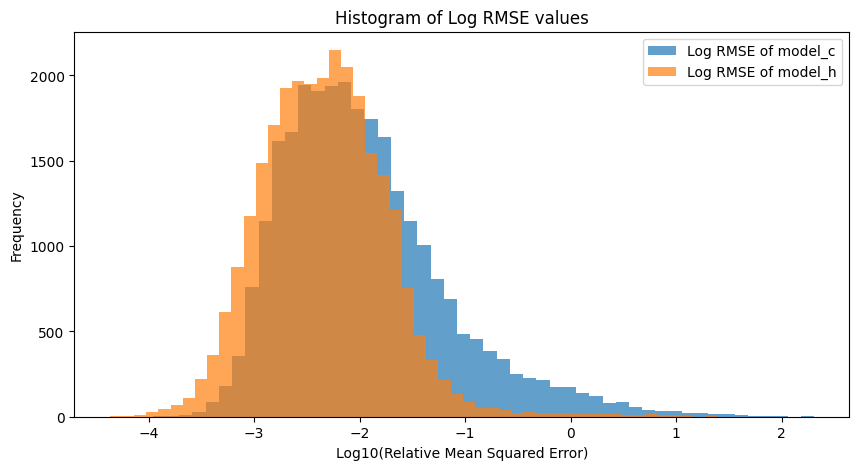

RMSE at c = 2: Mean = 0.06907425075769424, Std = 0.17987985908985138
RMSE at c = 3: Mean = 0.3499150574207306, Std = 0.8919644951820374
RMSE at c = 4: Mean = 0.4014701545238495, Std = 1.1836981773376465


In [ ]:
# Use trained model to make predictions
predictions_c = model_c.predict((data_i_test_pca, t))  # Ensure model_c is defined
predictions_h = model_h.predict((data_i_test_pca, t))  # Ensure model_h is defined

# Compute Relative Mean Squared Error (RMSE) for model_c
rmse_c = np.mean((predictions_c - data_c_test) ** 2 / (data_c_test ** 2 + 1e-8), axis=1)  # Averaging across time points
rmse_h = np.mean((predictions_h - data_h_test) ** 2 / (data_h_test ** 2 + 1e-8), axis=1)  # Averaging across time points

# Log-scale histogram
plt.figure(figsize=(10, 5))
plt.hist(np.log10(rmse_c + 1e-8), bins=50, alpha=0.7, label='Log RMSE of model_c')
plt.hist(np.log10(rmse_h + 1e-8), bins=50, alpha=0.7, label='Log RMSE of model_h')
plt.xlabel('Log10(Relative Mean Squared Error)')
plt.ylabel('Frequency')
plt.title('Histogram of Log RMSE values')
plt.legend()
plt.show()

# Inspect performance for c = 2, 3, 4
special_points = [2, 3, 4]
errors_at_special_points = {str(point): [] for point in special_points}

for i in range(data_c_test.shape[0]):
    for point in special_points:
        if np.max(data_c_test[i])>=point:
            index = np.argmin(np.abs(data_c_test[i]-point))
            errors_at_special_points[str(point)].append(np.abs((predictions_c[i, index] - data_c_test[i, index])**2))

# Print analysis for special points
for point, errors in errors_at_special_points.items():
    if errors:
        print(f"RMSE at c = {point}: Mean = {np.mean(errors)}, Std = {np.std(errors)}")
    else:
        print(f"No data points found for c = {point}")


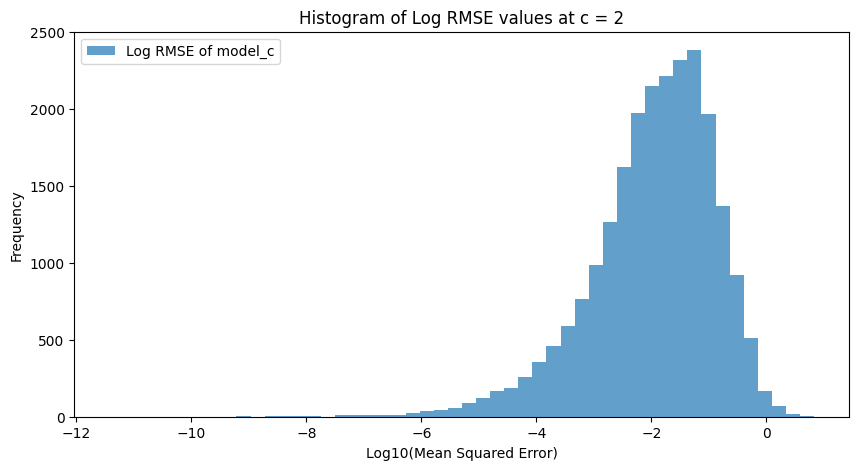

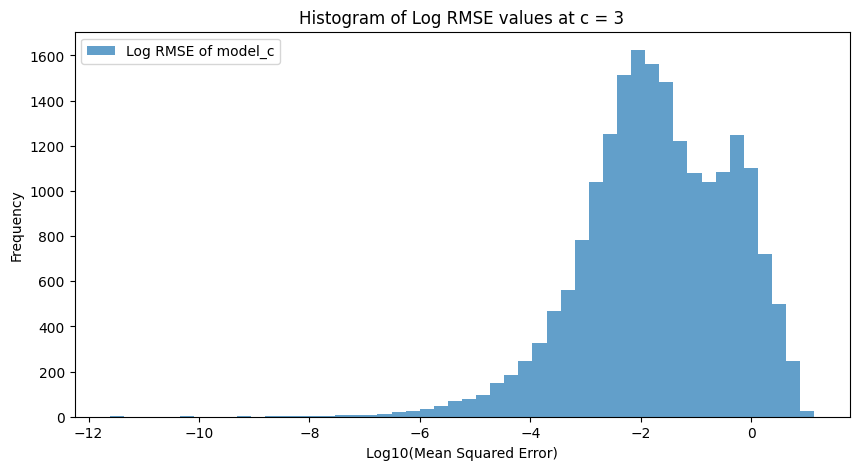

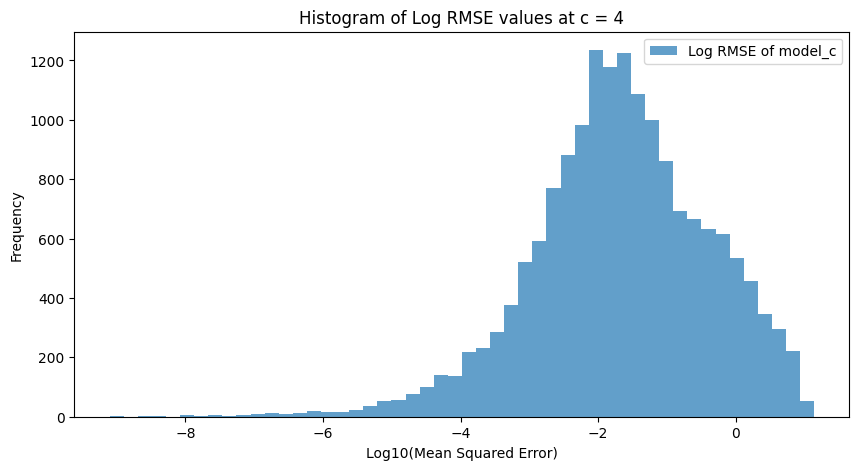

In [ ]:
plt.figure(figsize=(10, 5))
plt.hist(np.log10([error + 1e-12 for error in errors_at_special_points["2"]]), bins=50, alpha=0.7, label='Log RMSE of model_c')
plt.xlabel('Log10(Mean Squared Error)')
plt.ylabel('Frequency')
plt.title('Histogram of Log RMSE values at c = 2')
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.hist(np.log10([error + 1e-12 for error in errors_at_special_points["3"]]), bins=50, alpha=0.7, label='Log RMSE of model_c')
plt.xlabel('Log10(Mean Squared Error)')
plt.ylabel('Frequency')
plt.title('Histogram of Log RMSE values at c = 3')
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.hist(np.log10([error + 1e-12 for error in errors_at_special_points["4"]]), bins=50, alpha=0.7, label='Log RMSE of model_c')
plt.xlabel('Log10(Mean Squared Error)')
plt.ylabel('Frequency')
plt.title('Histogram of Log RMSE values at c = 4')
plt.legend()
plt.show()

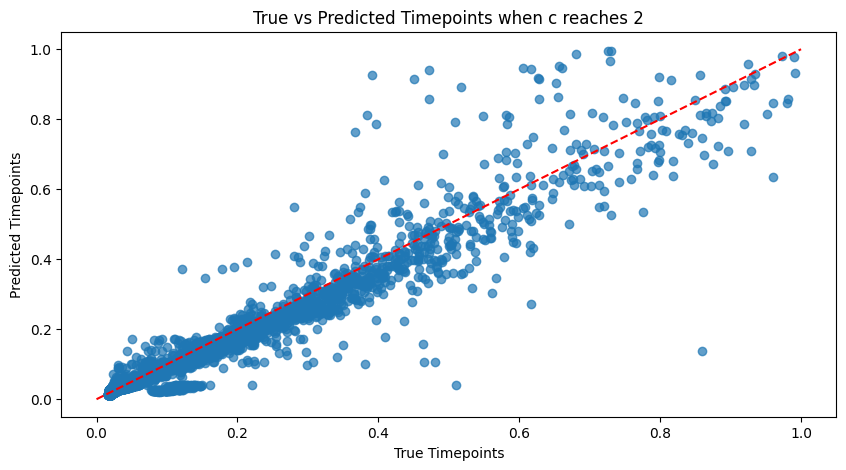

In [ ]:
# Identify the timepoints when true value and predicted value of c reach 2
true_timepoints = []
pred_timepoints = []

for i in range(data_c_test.shape[0]):
    true_indices = np.where(data_c_test[i] >= 2)[0]
    pred_indices = np.where(predictions_c[i] >= 2)[0]
    
    if len(true_indices) > 0 and len(pred_indices) > 0:
        true_timepoints.append(t[true_indices[0]])
        pred_timepoints.append(t[pred_indices[0]])

# Convert lists to numpy arrays for plotting
true_timepoints = np.array(true_timepoints)
pred_timepoints = np.array(pred_timepoints)

# Plot the true timepoints against the predicted timepoints
plt.figure(figsize=(10, 5))
plt.scatter(true_timepoints, pred_timepoints, alpha=0.7)
plt.plot([0, 1], [0, 1], 'r--')  # Line y=x for reference
plt.xlabel('True Timepoints')
plt.ylabel('Predicted Timepoints')
plt.title('True vs Predicted Timepoints when c reaches 2')
plt.show()

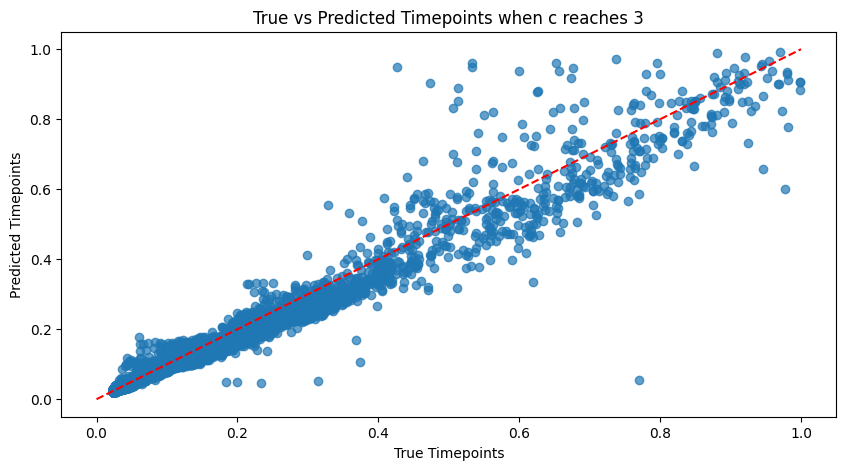

In [ ]:
# Identify the timepoints when true value and predicted value of c reach 2
true_timepoints = []
pred_timepoints = []

for i in range(data_c_test.shape[0]):
    true_indices = np.where(data_c_test[i] >= 3)[0]
    pred_indices = np.where(predictions_c[i] >= 3)[0]
    
    if len(true_indices) > 0 and len(pred_indices) > 0:
        true_timepoints.append(t[true_indices[0]])
        pred_timepoints.append(t[pred_indices[0]])

# Convert lists to numpy arrays for plotting
true_timepoints = np.array(true_timepoints)
pred_timepoints = np.array(pred_timepoints)

# Plot the true timepoints against the predicted timepoints
plt.figure(figsize=(10, 5))
plt.scatter(true_timepoints, pred_timepoints, alpha=0.7)
plt.plot([0, 1], [0, 1], 'r--')  # Line y=x for reference
plt.xlabel('True Timepoints')
plt.ylabel('Predicted Timepoints')
plt.title('True vs Predicted Timepoints when c reaches 3')
plt.show()

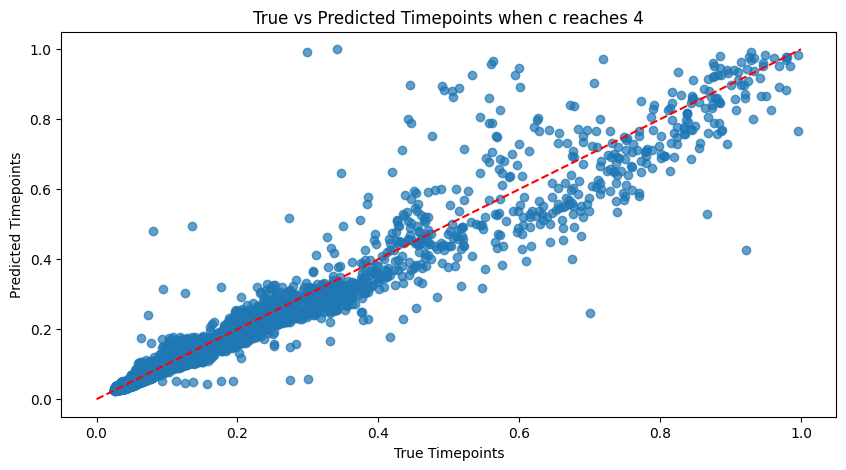

In [ ]:
# Identify the timepoints when true value and predicted value of c reach 2
true_timepoints = []
pred_timepoints = []

for i in range(data_c_test.shape[0]):
    true_indices = np.where(data_c_test[i] >= 4)[0]
    pred_indices = np.where(predictions_c[i] >= 4)[0]
    
    if len(true_indices) > 0 and len(pred_indices) > 0:
        true_timepoints.append(t[true_indices[0]])
        pred_timepoints.append(t[pred_indices[0]])

# Convert lists to numpy arrays for plotting
true_timepoints = np.array(true_timepoints)
pred_timepoints = np.array(pred_timepoints)

# Plot the true timepoints against the predicted timepoints
plt.figure(figsize=(10, 5))
plt.scatter(true_timepoints, pred_timepoints, alpha=0.7)
plt.plot([0, 1], [0, 1], 'r--')  # Line y=x for reference
plt.xlabel('True Timepoints')
plt.ylabel('Predicted Timepoints')
plt.title('True vs Predicted Timepoints when c reaches 4')
plt.show()

In [47]:
def find_sharpest_decline_point(data, mesh=np.linspace(0, 1, 601)):
    """
    Identifies the point where the second derivative is smallest for each function in the input matrix.
    
    Parameters:
        data (numpy.ndarray): A matrix of shape [n, 601] where each row represents a discretized function.
        mesh (numpy.ndarray): The mesh points corresponding to the function values (default: linspace(0, 1, 601)).
    
    Returns:
        numpy.ndarray: An array of shape [n] containing the mesh points where the second derivative is minimum.
    """
    h = mesh[1] - mesh[0]  # Step size
    n = data.shape[0]

    # Compute second derivative using finite difference approximation
    second_derivative = (data[:, :-2] + data[:, 2:] - 2 * data[:, 1:-1]) / (h ** 2)

    # Find the index of the minimum second derivative for each row
    min_indices = np.argmin(second_derivative, axis=1)

    # Map indices to corresponding mesh points
    min_points = mesh[min_indices + 1]  # +1 because second_derivative skips first and last points

    return min_points, min_indices

In [48]:
sharpest_points, sharpest_indices = find_sharpest_decline_point(data_c_test)

errors_at_sharpest_points = []

for i in range(data_c_test.shape[0]):
    errors_at_sharpest_points.append(np.abs((predictions_c[i, sharpest_indices[i]] - data_c_test[i, sharpest_indices[i]])**2))


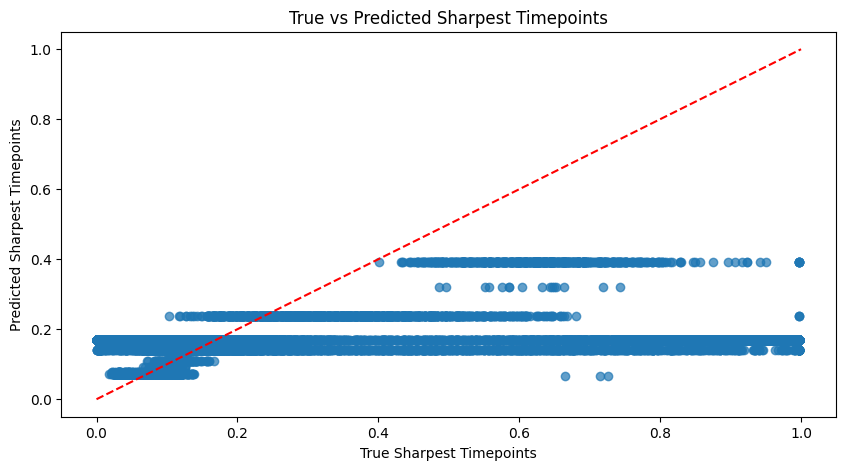

In [49]:
# Identify the timepoints where the true value and predicted value of c have the highest second derivative
true_sharpest_timepoints = []
pred_sharpest_timepoints = []

# Use the find_sharpest_decline_point function to find the sharpest decline points for predictions_c
_, pred_sharpest_indices = find_sharpest_decline_point(predictions_c)

for i in range(data_c_test.shape[0]):
    true_sharpest_timepoints.append(t[sharpest_indices[i]])
    pred_sharpest_timepoints.append(t[pred_sharpest_indices[i]])

# Convert lists to numpy arrays for plotting
true_sharpest_timepoints = np.array(true_sharpest_timepoints)
pred_sharpest_timepoints = np.array(pred_sharpest_timepoints)

# Plot the true sharpest timepoints against the predicted sharpest timepoints
plt.figure(figsize=(10, 5))
plt.scatter(true_sharpest_timepoints, pred_sharpest_timepoints, alpha=0.7)
plt.plot([0, 1], [0, 1], 'r--')  # Line y=x for reference
plt.xlabel('True Sharpest Timepoints')
plt.ylabel('Predicted Sharpest Timepoints')
plt.title('True vs Predicted Sharpest Timepoints')
plt.show()

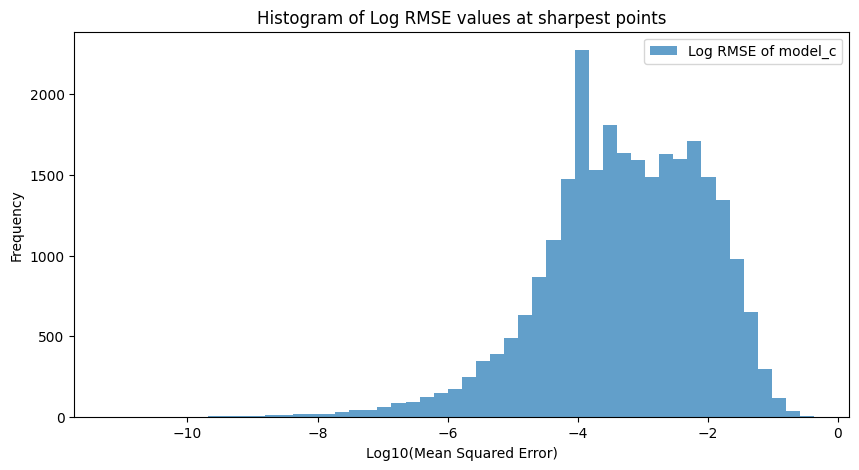

In [50]:
plt.figure(figsize=(10, 5))
plt.hist(np.log10([error + 1e-12 for error in errors_at_sharpest_points]), bins=50, alpha=0.7, label='Log RMSE of model_c')
plt.xlabel('Log10(Mean Squared Error)')
plt.ylabel('Frequency')
plt.title('Histogram of Log RMSE values at sharpest points')
plt.legend()
plt.show()

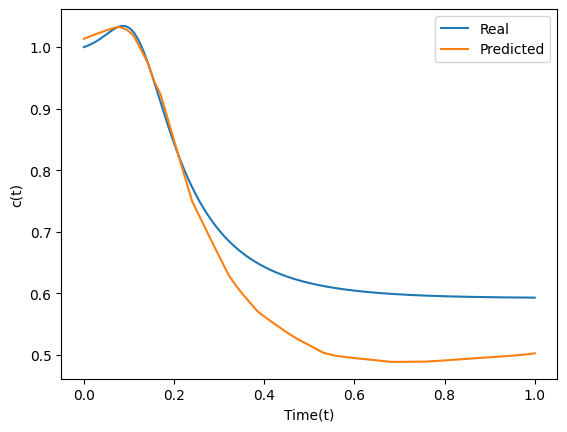

In [51]:
n = np.random.randint(0, len(data_h_test))
pred_c = model_c.predict((data_i_test_pca[n].reshape(1, -1), t))
plt.figure()
plt.plot(t, data_c_test[n], label="Real")
plt.plot(t, pred_c.T, label="Predicted")
plt.xlabel("Time(t)")
plt.ylabel("c(t)")
plt.legend()
plt.show()

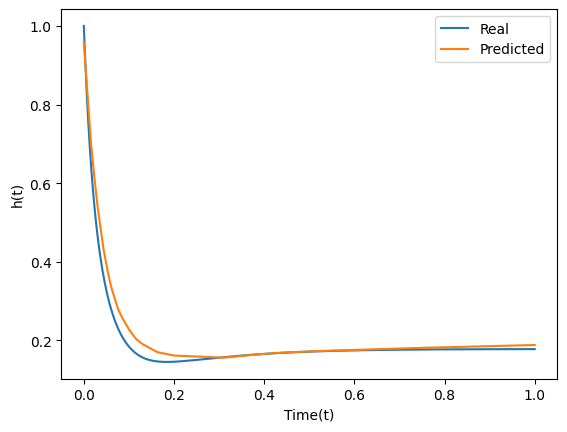

In [52]:
pred_h = model_h.predict((data_i_test_pca[n].reshape(1, -1), t))
plt.figure()
plt.plot(t, data_h_test[n], label="Real")
plt.plot(t, pred_h.T, label="Predicted")
plt.xlabel("Time(t)")
plt.ylabel("h(t)")
plt.legend()
plt.show()

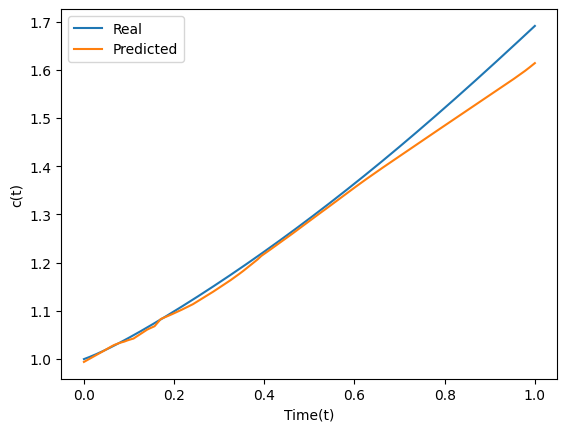

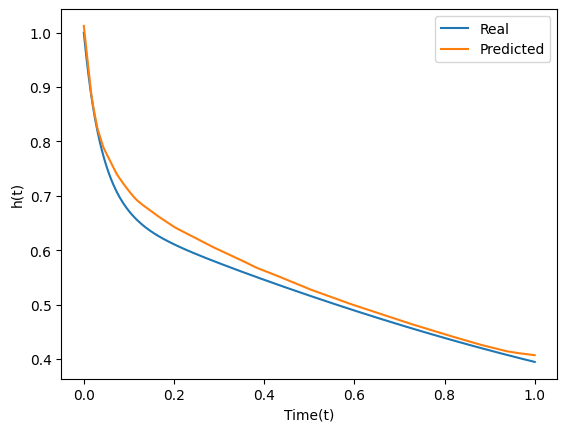

In [53]:
n = np.random.randint(0, len(data_h_test))
pred_c = model_c.predict((data_i_test_pca[n].reshape(1, -1), t))
plt.figure()
plt.plot(t, data_c_test[n], label="Real")
plt.plot(t, pred_c.T, label="Predicted")
plt.xlabel("Time(t)")
plt.ylabel("c(t)")
plt.legend()
plt.show()

pred_h = model_h.predict((data_i_test_pca[n].reshape(1, -1), t))
plt.figure()
plt.plot(t, data_h_test[n], label="Real")
plt.plot(t, pred_h.T, label="Predicted")
plt.xlabel("Time(t)")
plt.ylabel("h(t)")
plt.legend()
plt.show()

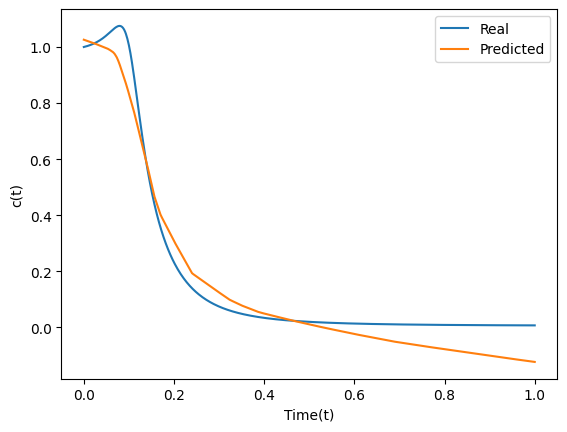

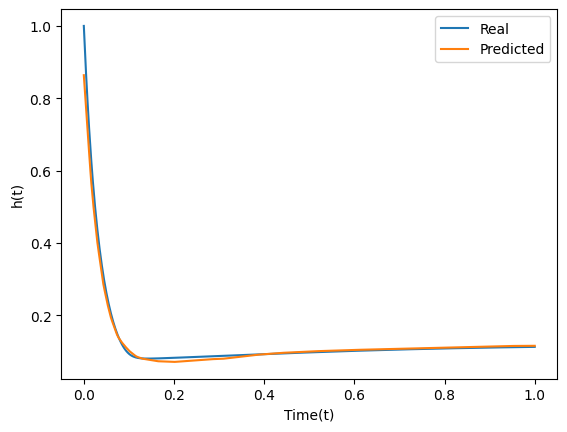

In [54]:
n = np.random.randint(0, len(data_h_test))
pred_c = model_c.predict((data_i_test_pca[n].reshape(1, -1), t))
plt.figure()
plt.plot(t, data_c_test[n], label="Real")
plt.plot(t, pred_c.T, label="Predicted")
plt.xlabel("Time(t)")
plt.ylabel("c(t)")
plt.legend()
plt.show()

pred_h = model_h.predict((data_i_test_pca[n].reshape(1, -1), t))
plt.figure()
plt.plot(t, data_h_test[n], label="Real")
plt.plot(t, pred_h.T, label="Predicted")
plt.xlabel("Time(t)")
plt.ylabel("h(t)")
plt.legend()
plt.show()

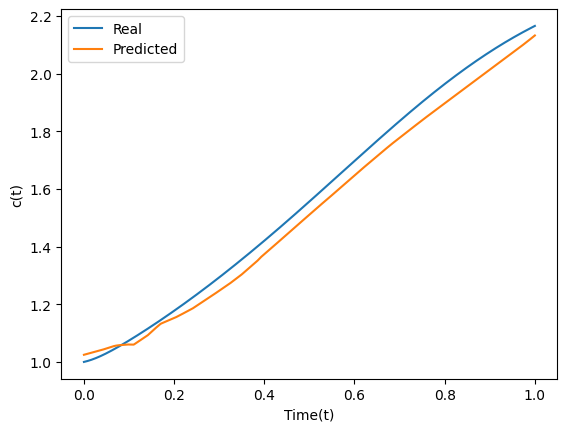

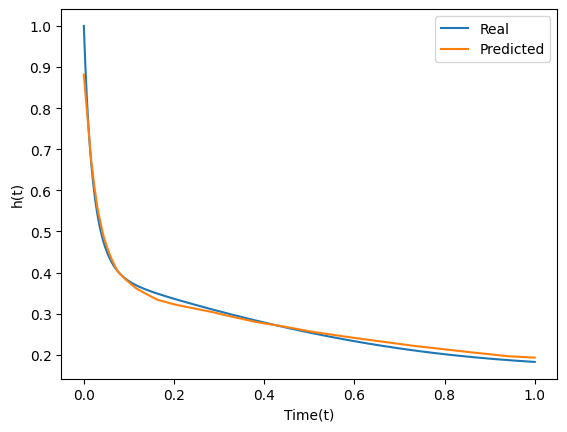

In [55]:
n = np.random.randint(0, len(data_h_test))
pred_c = model_c.predict((data_i_test_pca[n].reshape(1, -1), t))
plt.figure()
plt.plot(t, data_c_test[n], label="Real")
plt.plot(t, pred_c.T, label="Predicted")
plt.xlabel("Time(t)")
plt.ylabel("c(t)")
plt.legend()
plt.show()

pred_h = model_h.predict((data_i_test_pca[n].reshape(1, -1), t))
plt.figure()
plt.plot(t, data_h_test[n], label="Real")
plt.plot(t, pred_h.T, label="Predicted")
plt.xlabel("Time(t)")
plt.ylabel("h(t)")
plt.legend()
plt.show()

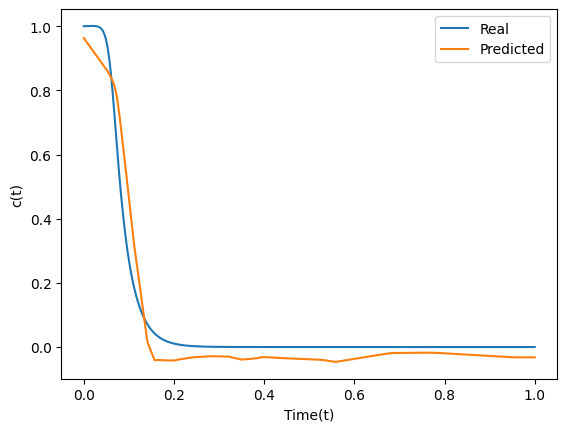

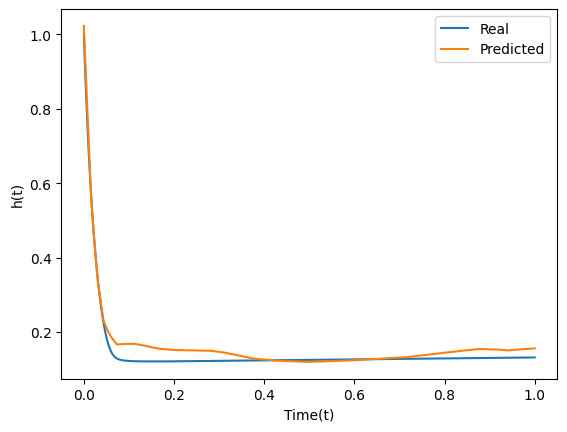

In [56]:
n = np.random.randint(0, len(data_h_test))
pred_c = model_c.predict((data_i_test_pca[n].reshape(1, -1), t))
plt.figure()
plt.plot(t, data_c_test[n], label="Real")
plt.plot(t, pred_c.T, label="Predicted")
plt.xlabel("Time(t)")
plt.ylabel("c(t)")
plt.legend()
plt.show()

pred_h = model_h.predict((data_i_test_pca[n].reshape(1, -1), t))
plt.figure()
plt.plot(t, data_h_test[n], label="Real")
plt.plot(t, pred_h.T, label="Predicted")
plt.xlabel("Time(t)")
plt.ylabel("h(t)")
plt.legend()
plt.show()

In [57]:
path = "C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/model_c_deeponet_pca"
model_c.save(path)

'C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/model_c_deeponet_pca-2000.pt'

In [58]:
path = "C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/model_h_deeponet_pca"
model_h.save(path)

'C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/model_h_deeponet_pca-2000.pt'

In [59]:
datastore_glob = h5py.File("C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/datasets/all_data_1d_glob.jld2", 'r')
print(datastore_glob.keys())
data_I_glob = np.array(np.array(datastore_glob["data_I"]))

data_c_glob = np.array(np.array(datastore_glob["data_c"]))
data_h_glob = np.array(np.array(datastore_glob["data_h"]))
para_glob = np.array(np.array(datastore_glob["para3"]))


<KeysViewHDF5 ['data_I', 'data_c', 'data_h', 'para3']>


In [60]:
data_i_glob_pca = pca_i.transform(data_I_glob)

In [61]:
# Apply inverse PCA transformation
data_i_glob_reconstructed = pca_i.inverse_transform(data_i_glob_pca)

# Calculate mean squared error
mse_glob = np.mean((data_I_glob - data_i_glob_reconstructed) ** 2)
print(f"Mean Squared Error for data_i_glob: {mse_glob}")

Mean Squared Error for data_i_glob: 0.00036515657600351707


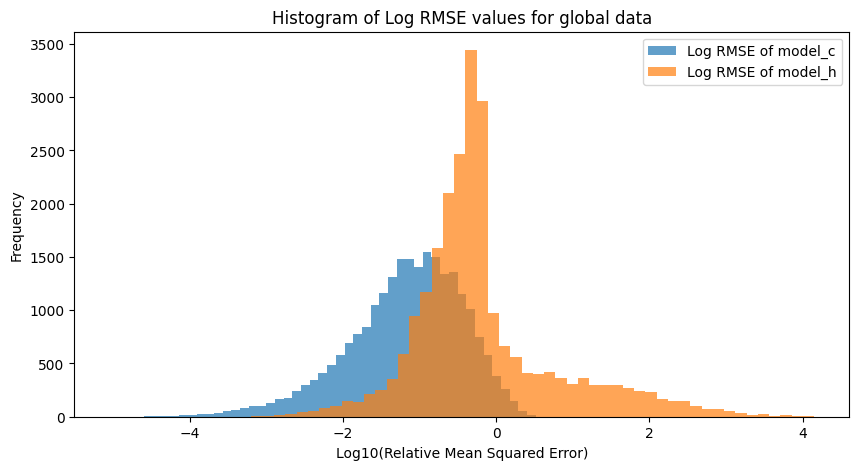

RMSE at c = 2: Mean = 1.4299097061157227, Std = 2.2039854526519775
RMSE at c = 3: Mean = 1.8517884016036987, Std = 3.2659366130828857
RMSE at c = 4: Mean = 2.7784271240234375, Std = 3.7827658653259277


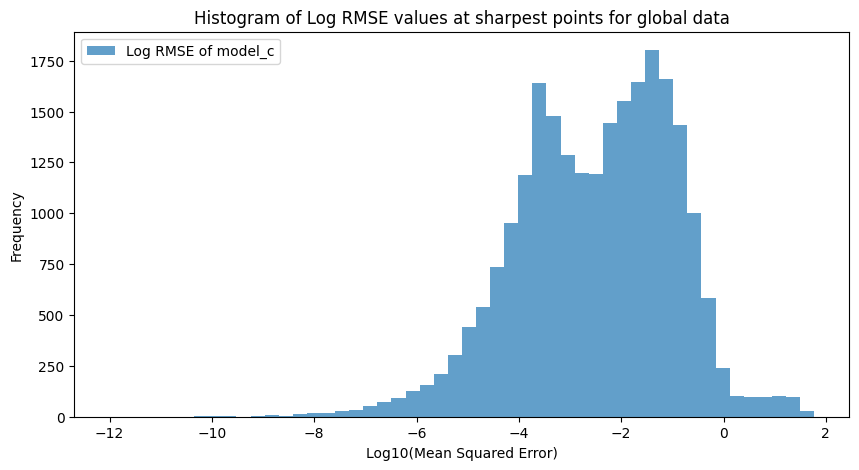

In [62]:
# Prepare the test data
X_test_glob = (data_i_glob_pca.astype(np.float32), t.astype(np.float32))
y_test_c_glob = data_c_glob.astype(np.float32)
y_test_h_glob = data_h_glob.astype(np.float32)

# Use trained models to make predictions
predictions_c_glob = model_c.predict(X_test_glob)
predictions_h_glob = model_h.predict(X_test_glob)

# Compute Relative Mean Squared Error (RMSE) for model_c
rmse_c_glob = np.mean((predictions_c_glob - y_test_c_glob) ** 2 / (y_test_c_glob ** 2 + 1e-12), axis=1)
rmse_h_glob = np.mean((predictions_h_glob - y_test_h_glob) ** 2 / (y_test_h_glob ** 2 + 1e-12), axis=1)

# Log-scale histogram
plt.figure(figsize=(10, 5))
plt.hist(np.log10(rmse_c_glob + 1e-8), bins=50, alpha=0.7, label='Log RMSE of model_c')
plt.hist(np.log10(rmse_h_glob + 1e-8), bins=50, alpha=0.7, label='Log RMSE of model_h')
plt.xlabel('Log10(Relative Mean Squared Error)')
plt.ylabel('Frequency')
plt.title('Histogram of Log RMSE values for global data')
plt.legend()
plt.show()

# Inspect performance for c = 2, 3, 4
special_points_glob = [2, 3, 4]
errors_at_special_points_glob = {str(point): [] for point in special_points_glob}

for i in range(y_test_c_glob.shape[0]):
    for point in special_points_glob:
        if np.max(y_test_c_glob[i]) >= point:
            index = np.argmin(np.abs(y_test_c_glob[i] - point))
            errors_at_special_points_glob[str(point)].append(np.abs((predictions_c_glob[i, index] - y_test_c_glob[i, index]) ** 2))

# Print analysis for special points
for point, errors in errors_at_special_points_glob.items():
    if errors:
        print(f"RMSE at c = {point}: Mean = {np.mean(errors)}, Std = {np.std(errors)}")
    else:
        print(f"No data points found for c = {point}")

# Find the sharpest decline points
sharpest_points_glob, sharpest_indices_glob = find_sharpest_decline_point(data_c_glob)

errors_at_sharpest_points_glob = []

for i in range(y_test_c_glob.shape[0]):
    errors_at_sharpest_points_glob.append(np.abs((predictions_c_glob[i, sharpest_indices_glob[i]] - y_test_c_glob[i, sharpest_indices_glob[i]]) ** 2))

# Plot histogram of RMSE values at sharpest points
plt.figure(figsize=(10, 5))
plt.hist(np.log10([error + 1e-12 for error in errors_at_sharpest_points_glob]), bins=50, alpha=0.7, label='Log RMSE of model_c')
plt.xlabel('Log10(Mean Squared Error)')
plt.ylabel('Frequency')
plt.title('Histogram of Log RMSE values at sharpest points for global data')
plt.legend()
plt.show()